### **Notebook 02** : Logistic Regression — Model Training & Experimentation
### **Input**  : X_train/test, y_train/test (from Notebook 01), scaler.pkl
### **Output** : lr_model.pkl, experiment results table

---
### Imports

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.titlesize'] = 13

print('Imports successful')

Imports successful


### Load data

Loads the preprocessed train/test splits produced by Notebook 01.
Features (`X`) and labels (`y`) are loaded separately for both sets.

In [19]:
# Data paths
DATA_DIR      = '../outputs/csv/'
OUT_DIR       = '../outputs/'


X_train = pd.read_csv(DATA_DIR + 'X_train.csv')
X_test  = pd.read_csv(DATA_DIR + 'X_test.csv')
y_train = pd.read_csv(DATA_DIR + 'y_train.csv').squeeze()
y_test  = pd.read_csv(DATA_DIR + 'y_test.csv').squeeze()

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'Class balance (train) — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()} ({y_train.mean():.1%} positive)')
X_train.head()

X_train : (2883, 6)   X_test : (721, 6)
Class balance (train) — 0: 1416  1: 1467 (50.9% positive)


,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,PurchaseSpanDays
0,140,2,662.08,331.040000,17,70
1,53,4,2411.82,602.955000,195,154
2,8,3,534.12,178.040000,35,245
3,112,1,308.68,308.680000,18,0
4,9,3,469.00,156.333333,57,197


In [20]:
print(list(X_train.columns))

['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'PurchaseSpanDays']


### Feature transformation - Transform existing features to improve model performance

Base features were extracted from raw UCI Online Retail transactional data 
as per-customer behavioural summaries.

Additional features are constructed via **feature transformation** to improve 
model performance:
- **Log transforms** : reduce skewness in tailed distributions
- **Ratio features** : capture relationships between existing features
- **Binning** : converts continuous values into ordinal categories

In [21]:
def add_engineered_features(df):
    df = df.copy()

    # Log transforms (reduce skew for LR) 
    df['LogRecency']   = np.log1p(df['Recency'])
    df['LogMonetary']  = np.log1p(df['Monetary'])
    df['LogFrequency'] = np.log1p(df['Frequency'])

    # Ratio features 
    df['FreqPerSpanDay']  = df['Frequency'] / (df['PurchaseSpanDays'] + 1)   # avoid div/0
    df['MonetaryPerFreq'] = df['Monetary']  / (df['Frequency'] + 1)

    # Recency bucket (ordinal 0–4, lower = more recent) 
    df['RecencyBucket'] = pd.cut(df['Recency'], bins=5, labels=False)

    return df

# include new feature into the X_train and X_test dataframes
X_train = add_engineered_features(X_train)
X_test  = add_engineered_features(X_test)

print('Engineered features added. Available columns:')
print(list(X_train.columns))
print(X_train.shape, X_test.shape)

Engineered features added. Available columns:
['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'PurchaseSpanDays', 'LogRecency', 'LogMonetary', 'LogFrequency', 'FreqPerSpanDay', 'MonetaryPerFreq', 'RecencyBucket']
(2883, 12) (721, 12)


### Experiment Configurations

Central configuration for the experiment. Adjust the settings below to 
control feature selection, scaling, and model hyperparameters — then 
re-run from Section 5 onwards to see the impact.

- **`FEATURE_COLS`** — select which features to include in training
- **`SCALER_TYPE`** — normalization method (`standard` / `minmax` / `robust`)
- **`MODEL_PARAMS`** — logistic regression hyperparameters (`C`, `penalty`, `solver`)

In [22]:
# Feature selections for the training
FEATURE_COLS = [
    'Recency',           # days since last purchase
    'Frequency',         # number of orders
    'Monetary',          # total spend
    'AvgOrderValue',     # average order size
    'UniqueProducts',    # variety of items bought
    'PurchaseSpanDays',  # days between first and last purchase
    'LogRecency',
    'LogMonetary',
    'LogFrequency', 
    'FreqPerSpanDay',
    'RecencyBucket'
]

# Select scaler type | standard, minmax, robust
SCALER_TYPE = "minmax"

# Model trianing hyperparameters
MODEL_PARAMS  = dict(
    C = 0.1,       # regularisation strength — smaller = stronger reg
    penalty = 'l2',      # 'l1' | 'l2' | 'elasticnet' | None
    solver = 'saga',   # 'lbfgs' | 'saga' | 'liblinear'
    max_iter = 2000,
    random_state = 42,
)

print('Config loaded.')
print(f'  Features      : {FEATURE_COLS}')
print(f'  Scaling       : {SCALER_TYPE}')
print(f'  C / penalty   : {MODEL_PARAMS["C"]} / {MODEL_PARAMS["penalty"]}')

Config loaded.
  Features      : ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'PurchaseSpanDays', 'LogRecency', 'LogMonetary', 'LogFrequency', 'FreqPerSpanDay', 'RecencyBucket']
  Scaling       : minmax
  C / penalty   : 0.1 / l2


### Prepare Data for Training

Validates that all configured features exist in the dataset before training.
Selected features are extracted from the train/test splits and scaled using
the normalisation method defined in `SCALER_TYPE` (`standard` / `minmax` / `robust`).
The scaler is **fit on training data only** and applied to the test set to
prevent data leakage.

In [23]:
# check features are available
missing_cols = [c for c in FEATURE_COLS if c not in X_train.columns]
if missing_cols:
    raise ValueError(f'These features are not in the dataset: {missing_cols}\n'
                     f'Run Section 4 first, or check for typos in FEATURE_COLS.')

Xtr = X_train[FEATURE_COLS].copy()
Xte = X_test[FEATURE_COLS].copy()

# scaling
if SCALER_TYPE:
    scalers = {
        'standard' : StandardScaler(),
        'minmax'   : MinMaxScaler(),
        'robust'   : RobustScaler(),
    }
    scaler = scalers[SCALER_TYPE]
    Xtr = pd.DataFrame(scaler.fit_transform(Xtr), columns=FEATURE_COLS)
    Xte = pd.DataFrame(scaler.transform(Xte),     columns=FEATURE_COLS)
    print(f'Scaling applied: {SCALER_TYPE}')
else:
    print('No scaling applied.')


print(f'\nFinal training shape : {Xtr.shape}')
print(f'Features used        : {FEATURE_COLS}')

Scaling applied: minmax

Final training shape : (2883, 11)
Features used        : ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'PurchaseSpanDays', 'LogRecency', 'LogMonetary', 'LogFrequency', 'FreqPerSpanDay', 'RecencyBucket']


### Baseline Model Training with all features
Trains a quick logistic regression model using the current configuration to 
verify the pipeline is working correctly. This is not the final model, 
results here serve as an initial sanity check before further experimentation.

In [24]:
# Build model params
params = MODEL_PARAMS.copy()

model = LogisticRegression(**params)
model.fit(Xtr, y_train)

print('Model trained.')
print(f'  Params : {params}')

Model trained.
  Params : {'C': 0.1, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 2000, 'random_state': 42}


Baseline model evaluation

In [25]:
y_pred      = model.predict(Xte)
y_prob      = model.predict_proba(Xte)[:, 1]

acc   = accuracy_score(y_test, y_pred)
roc   = roc_auc_score(y_test, y_prob)
f1    = f1_score(y_test, y_pred)

print('=' * 45)
print(f'  Accuracy   : {acc:.4f}')
print(f'  ROC-AUC    : {roc:.4f}')
print(f'  F1 Score   : {f1:.4f}')
print('=' * 45)
print()
print(classification_report(y_test, y_pred, target_names=['No Return (0)', 'Will Return (1)']))

  Accuracy   : 0.6990
  ROC-AUC    : 0.7796
  F1 Score   : 0.6982

                 precision    recall  f1-score   support

  No Return (0)       0.69      0.71      0.70       354
Will Return (1)       0.71      0.68      0.70       367

       accuracy                           0.70       721
      macro avg       0.70      0.70      0.70       721
   weighted avg       0.70      0.70      0.70       721



### Logistic Regression Regularization Sweep (C) - Performance Analysis

Evaluates how different values of regularization strength C affect Logistic Regression performance. The model is trained for multiple C values and compared using Accuracy, ROC-AUC, and F1-score. Results are plotted on a logarithmic scale to identify the optimal regularization level that balances bias and variance.

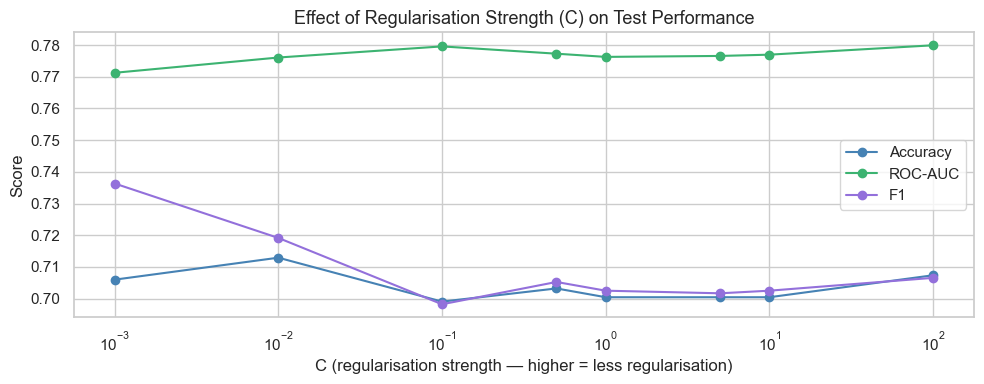

      C  Accuracy  ROC-AUC       F1
  0.001  0.705964 0.771271 0.736318
  0.010  0.712899 0.776090 0.719132
  0.100  0.699029 0.779599 0.698192
  0.500  0.703190 0.777298 0.705234
  1.000  0.700416 0.776290 0.702479
  5.000  0.700416 0.776590 0.701657
 10.000  0.700416 0.776990 0.702479
100.000  0.707351 0.779954 0.706537


In [29]:
C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]
results  = []

for c in C_values:
    p = params.copy()
    p['C'] = c
    m = LogisticRegression(**p).fit(Xtr, y_train)
    yp = m.predict(Xte)
    ypr = m.predict_proba(Xte)[:,1]
    results.append({
        'C'       : c,
        'Accuracy': accuracy_score(y_test, yp),
        'ROC-AUC' : roc_auc_score(y_test, ypr),
        'F1'      : f1_score(y_test, yp)
    })

sweep_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 4))
for metric, color in [('Accuracy','steelblue'), ('ROC-AUC','mediumseagreen'), ('F1','mediumpurple')]:
    ax.plot(sweep_df['C'], sweep_df[metric], marker='o', label=metric, color=color)
ax.set_xscale('log')
ax.set_xlabel('C (regularisation strength — higher = less regularisation)')
ax.set_ylabel('Score')
ax.set_title('Effect of Regularisation Strength (C) on Test Performance')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'lr_c_sweep.png', bbox_inches='tight')
plt.show()

print(sweep_df.to_string(index=False))

Based on the regularization sweep results, **C = 1** was selected as the optimal value. At this point, the model achieves a strong balance across **Accuracy, ROC-AUC, and F1-score**, while maintaining stable generalization performance. Increasing C beyond 1 provides minimal improvement, indicating diminishing returns from reducing regularization further. Therefore, **C = 1** is chosen as it offers a reliable trade-off between model complexity and predictive performance.
